# Volatility — cross-model evaluation

Pulls together the per-model outputs written by `01`–`04` and compares them on a common
footing.

| Model | Notebook | Features |
|---|---|---|
| GARCH(1,1) | `01_garch` | weekly returns (parametric) |
| Naïve | `02_har` | $\text{RV}_{t-1}$ |
| HAR-RV | `02_har` | 3 HAR lags |
| Random Forest | `03_random_forest` | HAR + EXOG |
| XGBoost | `04_xgboost` | HAR + EXOG |

Run `00`–`04` first so their `metrics_*` / `pred_*` / `period_*` CSVs are fresh.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vol_utils import vol_diebold_mariano
import warnings; warnings.filterwarnings('ignore')

PROC   = '../../data/processed'
MODELS = ['garch', 'har', 'rf', 'xgb']

metrics = pd.concat([pd.read_csv(f'{PROC}/metrics_{m}_volatility.csv') for m in MODELS],
                    ignore_index=True)
preds   = {m: pd.read_csv(f'{PROC}/pred_{m}_volatility.csv',
                          parse_dates=['Date']).set_index('Date') for m in MODELS}
print('loaded', len(metrics), 'metric rows from', len(MODELS), 'notebooks')


loaded 5 metric rows from 4 notebooks


## 1. Combined results table

All models on RMSE / MAE / $R^2$ / DCA, sorted by RMSE (lower is better). Saved to
`metrics_volatility_summary.csv`.


In [2]:
metrics_sorted = metrics.sort_values('rmse').reset_index(drop=True)
metrics_sorted.to_csv(f'{PROC}/metrics_volatility_summary.csv', index=False)
metrics_sorted.round(5)


,model,rmse,mae,r2,dca
0,HAR-RV,0.03205,0.01638,0.28985,0.70286
1,"GARCH(1,1)",0.03296,0.01824,0.24899,0.67429
2,RF (HAR+EXOG),0.03311,0.01733,0.24226,0.68571
3,XGB (HAR+EXOG),0.03436,0.01776,0.18361,0.68571
4,Naive (RV_t-1),0.03979,0.02013,-0.09462,0.00000


## 2. Sub-period breakdown

Per-year RMSE and DCA for each model (Naïve excluded — it has no `period_*` file of its
own). Saved to `period_volatility_summary.csv`.


In [3]:
period_all = []
for m in MODELS:
    p = pd.read_csv(f'{PROC}/period_{m}_volatility.csv')
    p.insert(0, 'model', m.upper())
    period_all.append(p)
period_all = pd.concat(period_all, ignore_index=True)
period_all.to_csv(f'{PROC}/period_volatility_summary.csv', index=False)
period_all.round(4)


,model,Period,n,RMSE,MAE,DCA
0,GARCH,2023 (choppy),52,0.0162,0.0140,0.6731
1,GARCH,2024 (bull start),52,0.0145,0.0122,0.7885
2,GARCH,2025 (bull run),52,0.0251,0.0195,0.6346
3,GARCH,2026 (YTD),19,0.0836,0.0431,0.4737
4,GARCH,── Full test ──,175,0.0330,0.0182,0.6743
5,HAR,2023 (choppy),52,0.0148,0.0122,0.6923
6,HAR,2024 (bull start),52,0.0146,0.0115,0.7885
7,HAR,2025 (bull run),52,0.0222,0.0155,0.6731
8,HAR,2026 (YTD),19,0.0832,0.0436,0.5789
9,HAR,── Full test ──,175,0.0321,0.0164,0.7029


## 3. 2026 zoom — actual vs each model

Same 2026 sanity-check view as the return notebooks: actual RV in black, each model
overlaid.


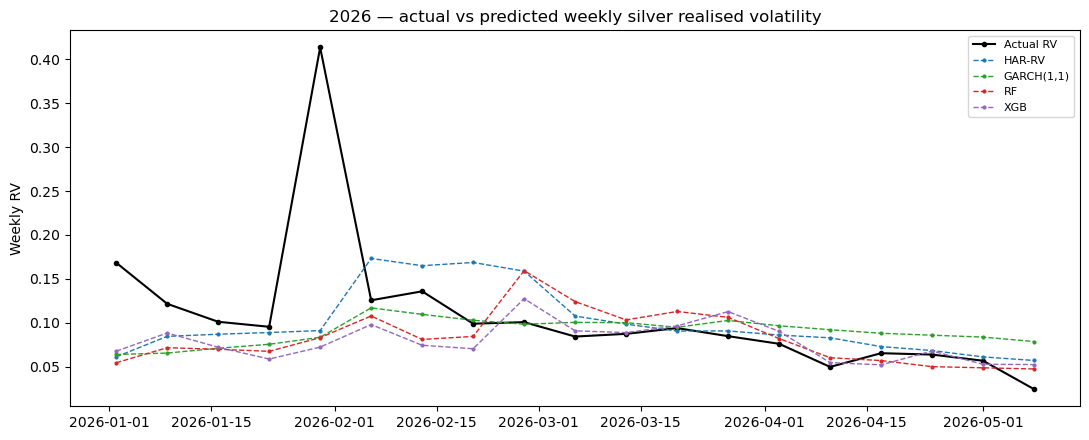

In [4]:
zoom = preds['har'][['actual']].copy()
zoom['Naive']      = preds['har']['naive']
zoom['HAR-RV']     = preds['har']['har']
zoom['GARCH(1,1)'] = preds['garch']['garch']
zoom['RF']         = preds['rf']['rf']
zoom['XGB']        = preds['xgb']['xgb']
zoom = zoom.loc['2026-01-01':]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(zoom.index, zoom['actual'], 'k-', lw=1.5, marker='o', ms=3, label='Actual RV')
for col, c in zip(['HAR-RV', 'GARCH(1,1)', 'RF', 'XGB'],
                  ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']):
    ax.plot(zoom.index, zoom[col], '--', lw=1, marker='.', ms=4, color=c, label=col)
ax.set_title('2026 — actual vs predicted weekly silver realised volatility')
ax.set_ylabel('Weekly RV'); ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 4. Diebold-Mariano tests

Each model against the Naïve floor — the Diebold-Mariano (1995) test with
Newey-West (1987) lag-1 variance, via `vol_diebold_mariano` in `vol_utils`. A negative
DM stat means the model has lower loss; the stars show whether the gap is significant.
Naïve is the baseline because it is the smallest possible model.

**The loss function matters here.** Weekly silver RV is extremely heavy-tailed — the
2026 spike weeks carry RV roughly 10× the median. Under **squared-error** loss a single
extreme week can account for ~80 % of the loss differential, which inflates the DM
variance and destroys the test's power even when a model's RMSE is clearly lower. The
volatility-forecasting literature (Patton 2011) therefore compares forecasts under
**QLIKE** — a proxy-robust, ratio-based loss that is far less sensitive to extreme
weeks. QLIKE-DM is reported as the **primary** test below; squared-error DM is kept
underneath as a reference.

The gap between the two is itself informative: a model can be steadily and
significantly better in normal weeks (QLIKE-significant) yet not separable under MSE,
because in the handful of extreme weeks *every* model is about equally wrong.

In [5]:
actual = preds['har']['actual'].values
naive  = preds['har']['naive'].values
model_preds = {'HAR-RV':     preds['har']['har'].values,
               'GARCH(1,1)': preds['garch']['garch'].values,
               'RF':         preds['rf']['rf'].values,
               'XGB':        preds['xgb']['xgb'].values}

dm_rows = []
print('QLIKE loss  --  primary test, robust to the extreme RV weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='qlike'))

print('\nSquared-error loss  --  reference, dominated by a few tail weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='mse'))

pd.DataFrame(dm_rows).to_csv(f'{PROC}/dm_volatility_summary.csv', index=False)

QLIKE loss  --  primary test, robust to the extreme RV weeks:
HAR-RV                       vs Naive         [qlike]  DM=-2.902  p=0.004  **    -> winner: HAR-RV
GARCH(1,1)                   vs Naive         [qlike]  DM=-2.594  p=0.009  **    -> winner: GARCH(1,1)
RF                           vs Naive         [qlike]  DM=-2.370  p=0.018  *     -> winner: RF
XGB                          vs Naive         [qlike]  DM=-1.466  p=0.143  (ns)  -> winner: tie

Squared-error loss  --  reference, dominated by a few tail weeks:
HAR-RV                       vs Naive         [mse  ]  DM=-1.255  p=0.209  (ns)  -> winner: tie
GARCH(1,1)                   vs Naive         [mse  ]  DM=-1.161  p=0.246  (ns)  -> winner: tie
RF                           vs Naive         [mse  ]  DM=-1.183  p=0.237  (ns)  -> winner: tie
XGB                          vs Naive         [mse  ]  DM=-1.117  p=0.264  (ns)  -> winner: tie


## 5. Sentiment ablation — does Reddit sentiment help?

The headline comparison above uses only price-derived features. A separate ablation in
`02_har` (§4), `03_random_forest` (§5) and `04_xgboost` (§5) tests whether **Reddit
sentiment** — post-volume *attention* and *sentiment intensity*, built in
`00_features` §5 — carries information about next-week RV beyond the HAR (and EXOG)
features. The motivation is the news→volatility channel (Engle & Ng 1993); the closest
published precedent is Audrino, Sigrist & Ballinari (2020).

Each family carries its own no-sentiment baseline; the `dm_qlike` / `dm_qlike_p`
columns give the QLIKE-DM stat vs that baseline (negative = the sentiment rung is
better; baseline rows are blank). The HAR block also reports the `HAR+EXOG` rung —
not as a sentiment control (it turns out worse than bare HAR on this sample) but as
the linear sibling of `RF/XGB (HAR+EXOG)`. The ablation is scored on the test weeks
where Reddit features exist (174 of 175 — the final 2026 week is dropped), so these
RMSEs are not byte-identical to the headline table above.

In [6]:
# Sentiment ablation — tables gathered from 01 / 03 / 04
sent_files = {'HAR': 'metrics_har_sentiment_volatility.csv',
              'RF':  'metrics_rf_sentiment_volatility.csv',
              'XGB': 'metrics_xgb_sentiment_volatility.csv'}
sent_all = []
for fam, fn in sent_files.items():
    s = pd.read_csv(f'{PROC}/{fn}')
    s.insert(0, 'family', fam)
    sent_all.append(s)
sent_all = pd.concat(sent_all, ignore_index=True)
sent_all.to_csv(f'{PROC}/metrics_sentiment_volatility_summary.csv', index=False)
print('Saved metrics_sentiment_volatility_summary.csv')
sent_all.round(5)

Saved metrics_sentiment_volatility_summary.csv


,family,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p
0,HAR,HAR,0.03205,0.01628,0.29277,0.70690,NaN,NaN
1,HAR,HAR+EXOG,0.03268,0.01654,0.26465,0.71839,2.13036,0.03314
2,HAR,HAR+Attention,0.03191,0.01622,0.29873,0.70690,-2.60988,0.00906
3,HAR,HAR+SentIntensity,0.03194,0.01620,0.29734,0.71264,-3.39661,0.00068
4,HAR,HAR+Attention+SentIntensity,0.03190,0.01620,0.29907,0.71839,-3.06176,0.00220
5,RF,RF (HAR),0.03177,0.01664,0.30496,0.71264,NaN,NaN
6,RF,RF (HAR+EXOG),0.03370,0.01754,0.21775,0.68966,1.49958,0.13372
7,RF,RF (HAR+Attention),0.03216,0.01749,0.28801,0.67816,2.52499,0.01157
8,RF,RF (HAR+SentIntensity),0.03232,0.01726,0.28076,0.70690,-0.23779,0.81204
9,RF,RF (HAR+Attention+SentIntensity),0.03235,0.01782,0.27925,0.71839,1.60994,0.10741


## 6. Conclusion

Read the tables above against these questions:

1. **Does HAR-RV beat Naïve on RMSE?** If yes, silver volatility has predictable
   structure beyond a pure random walk — consistent with the equity/FX literature.
2. **Does GARCH(1,1) beat HAR-RV?** On weekly equity-like series HAR usually wins;
   GARCH is parametric and assumes Gaussian innovations.
3. **Do the EXOG cross-asset RVs help?** Two complementary views. (a) The **linear
   sibling** `HAR+EXOG` in the `02_har` HAR-X ablation — if it beats HAR, linear
   cross-asset spillover carries weekly silver-vol signal; if it loses, the feature set
   itself is dry, and any failure of `RF/XGB (HAR+EXOG)` to beat HAR is a *feature*
   problem rather than a model-class one. (b) `RF/XGB (HAR+EXOG)` vs the linear sibling
   then isolates whatever the trees add (or lose) through nonlinearity. The feature
   importance plots in `03`/`04` show which cross-asset RVs the trees lean on.
4. **DCA** — vol rising vs falling is the trader-relevant binary. DCA > 0.55 is already
   useful for risk-management timing. (The Naïve DCA is ≈ 0 by construction: predicting
   last week's RV implies *no* change, so it can never call a direction.)
5. **Statistical significance** — read the **QLIKE-DM** row, not the squared-error row.
   Squared-error DM is near-powerless on this heavy-tailed RV target (one 2026 week
   carries ~80 % of the loss differential), so an RMSE improvement that is real and
   steady can still fail an MSE-DM test. QLIKE — the proxy-robust loss standard in the
   volatility literature — is the test to report; MSE-DM is kept only as a reference
   that demonstrates the heavy-tail problem.
6. **Does sentiment help?** The §5 ablation — read `dm_qlike` per family against bare
   `HAR` / `RF (HAR+EXOG)` / `XGB (HAR+EXOG)`. A negative, significant `dm_qlike` means
   the news→volatility channel is live for silver; a null says public sentiment adds
   nothing once the model's own-history (and cross-asset) information is in — a clean
   semi-strong-form companion to the returns side. (Note that on this sample the HAR
   block's own-history baseline is the *only* informative control — `HAR+EXOG` is
   itself worse than bare HAR.)